# DA5401W: Data Analytics Lab
### Mid Term Examination - March 8th, 2026
#### Optimization, Dimensionality Reduction, Clustering & Regression

**Course:** DA5401W — Data Analytics Lab

**Student Name:** Amardeep Kumar  
**Student ID:** DA25M502  

---

### Mark Scheme

| Section | Topic | Marks |
|---|---|---|
| Q1 | SciPy Optimisation | 5 |
| Q2 | PCA | 5 |
| Q3 | K-Means Clustering | 5 |
| Q4 | Agglomerative Clustering | 5 |
| Q5 | DBSCAN | 5 |
| Q6 | Linear Regression | 5 |
| **Total** | | **30** |


## Instructions

- This exam is worth **30 marks** in total.
- Run the **Setup** cell first before attempting any question.
- Store your results in the **exact variable names** specified in each question — these are used for auto-grading.
- Written answers must be entered in the designated grey answer cells.
- Do **not** rename or delete any cells.
- **Use of LLMs for generation of Code is strictly prohibited**. IF there is evidence of using LLMS .e.g. chatgpt, claude code, etc for coding then strict action will be taken

## Setup — Run this cell first, do not modify


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linprog
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

# Load dataset — works on Google Colab and local Otter Grader
import os
if os.path.exists('city_data.csv'):
    df = pd.read_csv('city_data.csv')
else:
    df = pd.read_csv('https://drive.google.com/uc?export=download&id=13mv-92pnMU-GyO1RWkprBeIUT-p1pifK')

features = ['gdp_per_capita', 'unemployment_rate', 'literacy_rate',
            'healthcare_index', 'green_space_pct', 'public_transport_score',
            'internet_penetration', 'crime_index']
X_raw = df[features].copy()
y = df['qol_index'].copy()
print(f'Dataset loaded: {df.shape[0]} cities, {len(features)} features')
print(f'Target (QoL Index) range: {y.min():.2f} to {y.max():.2f}')


Dataset loaded: 500 cities, 8 features
Target (QoL Index) range: 28.08 to 81.25


---
## Q1: SciPy Optimisation (5 marks)


### Q1a — Unconstrained Minimisation `[2 marks]`

A city planner wants to minimise the following cost function:

$$f(x_1, x_2) = (x_1 - 3)^2 + 2(x_2 - 2)^2 + x_1 x_2$$

Minimise $f(x_1, x_2)$ using `scipy.optimize.minimize` with `method='BFGS'`, starting from $x_0 = [0, 0]$. Print the optimal point and minimum value.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `opt_x1_unc` | `float` | Optimal value of x1 |
| `opt_x2_unc` | `float` | Optimal value of x2 |



In [ ]:
# Q1a: Unconstrained minimisation (BFGS)
# Graded: opt_x1_unc, opt_x2_unc
# YOUR CODE HERE
# intilization
x0 = np.array([0,0])
#objective function
def objective_fun(x):
  return (x[0]-3)**2 + 2*(x[1]-2)**2 + x[0]*x[1]
#objective function jacobian
def objective_fun_grad(x):
  dfdx1 = 2*(x[0]-3) + x[1]
  dfdx2 = 2*2*(x[1]-2) + x[0]
  return np.array([dfdx1,dfdx2])

res = minimize(fun = objective_fun, x0=x0,  method='BFGS', jac=objective_fun_grad)
opt_x1_unc = float(res.x[0])
opt_x2_unc = float(res.x[1])

print(f'x1 : {opt_x1_unc}')
print(f'x2 : {opt_x2_unc}')
print(f"minimum value : {res.fun}")
#res
# opt_x1_unc
# opt_x2_unc

x1 : 2.2857112583405996
x2 : 1.4285734982513805
minimum value : 4.428571428582895


In [ ]:
# help(minimize)
# minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)


### Q1b — Constrained Minimisation `[2 marks]`

Add the equality constraint $x_1 + x_2 = 4$ (total budget units) and re-solve using `method='SLSQP'`. Print the constrained solution and compare with Q1a.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `opt_x1_con` | `float` | Constrained optimal x1 |
| `opt_x2_con` | `float` | Constrained optimal x2 |



In [ ]:
# Q1b: Constrained minimisation (SLSQP) with x1 + x2 = 4
# Graded: opt_x1_con, opt_x2_con
# YOUR CODE HERE
from scipy.optimize import LinearConstraint
A = np.array([1,1])
lb = 4
ub = 4
constrain_1 = LinearConstraint(A=A,lb = lb,ub=ub)
res1 = minimize(fun = objective_fun, x0=x0,  method='SLSQP', jac=objective_fun_grad, constraints = [constrain_1])
opt_x1_con = float(res1.x[0])
opt_x2_con = float(res1.x[1])

print(f'x1 : {opt_x1_con}')
print(f'x2 : {opt_x2_con}')
#res
# opt_x1_unc
# opt_x2_unc
print(opt_x1_con > opt_x1_unc)
print(opt_x2_con > opt_x2_unc)

x1 : 2.5
x2 : 1.5000000000000004
True
True


In [ ]:
# help(LinearConstraint)
# LinearConstraint(A, lb=-inf, ub=inf, keep_feasible=False)

### Q1c — Linear Programming `[1 mark]`

A regional government allocates budget across three programmes. Use `scipy.optimize.linprog` to solve:

**Maximise:** $5H + 4E + 3I$ (social benefit)  
**Subject to:**  
- $6H + 4E + 2I \leq 240$ (budget constraint, million USD)  
- $3H + 2E + 5I \leq 270$ (workforce constraint, thousand staff)  
- $H, E, I \geq 0$

Print the optimal allocation and maximum social benefit.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `lp_benefit` | `float` | Maximum social benefit (positive value) |



In [ ]:
# Q1c: Linear programming (linprog) — maximise social benefit
# Graded: lp_benefit
# YOUR CODE HERE
c = [-5,-4,-3]
A_ub = np.array([[6,4,2],
                 [3,2,5]])
b_ub = np.array([240,270])
bounds = [(0,None),(0,None),(0,None)]
res2 = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
lp_benefit = float(-res2.fun)
print(f"optimal allocation : {res2.x}")
print(f"maximum benefit : {lp_benefit}")
# res2

optimal allocation : [ 0.   41.25 37.5 ]
maximum benefit : 277.5


In [ ]:
# help(linprog)
# linprog(c, A_ub=None, b_ub=None, A_eq=None, b_eq=None, bounds=(0, None), method='highs', callback=None, options=None, x0=None, integrality=None)

---
## Q2: Principal Component Analysis (5 marks)


### Q2a — Explained Variance `[2 marks]`

Standardise the 8 features using `StandardScaler`. Fit a **full PCA** (all 8 components) on the standardised data. Print the explained variance ratio for each component and state how many components are needed to explain at least **80%** of the total variance.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `X_scaled` | `ndarray` (500, 8) | Standardised feature matrix |
| `n_components` | `int` | Number of components explaining ≥ 80% variance |



In [ ]:
# Q2a: Standardise, fit full PCA, determine n_components
# Graded: X_scaled, n_components
# YOUR CODE HERE
#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# full pca
pca = PCA()
X_raw_scaled_pca = pca.fit_transform(X_scaled)
expalined_ratio = pca.explained_variance_ratio_

# explain 80% variance
cum_sum_var = np.cumsum(expalined_ratio)
n_components_80 = np.argmax(cum_sum_var>=0.8)+1
n_components = int(n_components_80)

print(f"scaled shape : {X_scaled.shape}")
print(f"explaind variance : {expalined_ratio}")
print(f"components : {n_components}")

scaled shape : (500, 8)
explaind variance : [0.71318782 0.06179522 0.05408035 0.04615381 0.03658557 0.03442849
 0.02805708 0.02571165]
components : 3


In [ ]:
#  help(pca)
#  explained_variance_ratio_

### Q2b — Dimensionality Reduction `[1 mark]`

Reduce the data to `n_components` components using a new PCA object. Print the shape of the reduced data and the exact percentage of total variance retained.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `X_pca` | `ndarray` (500, n_components) | PCA-reduced data — **used in Q3–Q6** |



In [ ]:
# Q2b: Reduce to n_components, store as X_pca
# Graded: X_pca
# YOUR CODE HERE
pca_new = PCA(n_components=3)
X_pca = pca_new.fit_transform(X_scaled)
expalined_ratio_new = pca_new.explained_variance_ratio_

print(f"shape : {X_pca.shape}")
print(f"variance retained : {np.sum(expalined_ratio_new)*100}%")

shape : (500, 3)
variance retained : 82.90633967323069%


### Q2c — Reconstruction Error `[2 marks]`

Use `pca_nd.inverse_transform()` to reconstruct the original standardised data from `X_pca`. Compute the **mean squared reconstruction error** between the original standardised data (`X_scaled`) and the reconstructed data.

Print the reconstruction error and write one sentence explaining what this value tells you about the information lost during dimensionality reduction.

**Required variables for auto-grading:**

| Variable | Type | Description |
|---|---|---|
| `reconstruction_error` | `float` | Mean squared error between `X_scaled` and its PCA reconstruction |


In [ ]:
# Q2c: Reconstruct data and compute mean squared reconstruction error
# Graded: reconstruction_error
# YOUR CODE HERE


**Q2c — What does the reconstruction error tell you? — Written answer:**

> *(Replace this text with your answer)*


---
## Q3: K-Means Clustering (5 marks)

> Use `X_pca` from Q2 for all clustering questions.


### Q3a — Choosing k `[2 marks]`

Run K-Means for **k = 2 to 8**. For each k, record the inertia and silhouette score. Print a table of k, inertia, and silhouette score. Plot the **silhouette score vs k**. Choose the best k and print a one-sentence justification.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `sil_scores` | `list` of 7 floats | Silhouette scores for k = 2, 3, …, 8 |
| `best_k` | `int` | Chosen number of clusters |



best_k :3
for elbow at K= 3 there is sudden drop in interia post that it shows gradual error and in silhouette score it achieve high score at 3.


(range(2, 9),
 [1344.666653322915,
  605.929676038193,
  528.5845093992377,
  453.5024413647407,
  412.26409206284455,
  378.2321169880557,
  353.56109719802964],
 [np.float64(0.4967655513794491),
  np.float64(0.5464762786897206),
  np.float64(0.4255007812349152),
  np.float64(0.33857260129672284),
  np.float64(0.3317446768117061),
  np.float64(0.2640561197087985),
  np.float64(0.24316968367962025)])

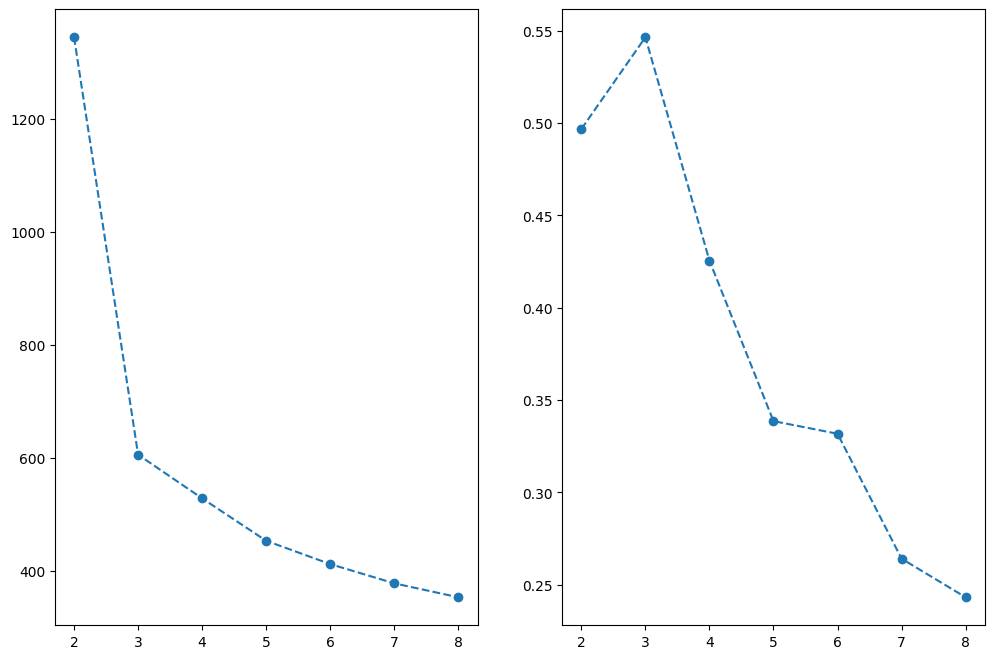

In [ ]:
# Q3a: K-Means for k=2 to 8, silhouette plot
# Graded: sil_scores, best_k
# YOUR CODE HERE
interia = []
sil_score = []
k_range = range(2,9)

for i in range(2,9):
  kmeans = KMeans(n_clusters= i,init='k-means++', n_init=5 )
  kmeans.fit(X_pca)
  interia.append(kmeans.inertia_)
  sil_score.append(silhouette_score(X_pca,labels=kmeans.labels_))

fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(12,8))
axes[0].plot(k_range,interia,marker = 'o',linestyle='--',label = 'interia')
axes[1].plot(k_range,sil_score,marker = 'o',linestyle='--',label = 'sil_score')

sil_scores = sil_score
best_k = 3
#print(f"sil_scores :{sil_scores}")
print(f"best_k :{best_k}")
print(f"for elbow at K= 3 there is sudden drop in interia post that it shows gradual error and in silhouette score it achieve high score at 3.")
k_range,interia,sil_scores

In [ ]:
# help(KMeans)
# KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
# help(silhouette_score)
# silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)

### Q3b — Fit K-Means `[1 mark]`

Fit K-Means with your chosen `best_k` on `X_pca`. Print the number of cities in each cluster.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `kmeans_labels` | `ndarray` (500,) | Cluster label for each city — **used in Q6** |



In [ ]:
# Q3b: Fit K-Means with best_k
# Graded: kmeans_labels
# YOUR CODE HERE
kmeans_3 = KMeans(n_clusters= 3,init='k-means++', n_init=5 )
kmeans_3.fit(X_pca)
kmeans_labels = kmeans_3.labels_
print(f"kmeans_labels : {kmeans_labels}")
print(f"kmeans_labels shape: {kmeans_labels.shape}")

kmeans_labels : [2 0 1 1 1 1 0 0 2 2 1 0 2 0 0 2 2 1 0 0 2 1 0 2 2 0 0 2 2 2 2 0 1 2 0 2 0
 0 2 1 2 1 2 0 0 1 2 0 2 0 1 2 2 0 1 1 0 0 1 0 2 2 0 0 0 1 2 0 0 2 2 0 2 0
 2 0 1 2 0 0 2 2 0 1 2 2 1 2 0 2 2 2 0 2 1 0 0 2 0 1 2 0 0 0 0 1 2 2 2 1 2
 0 0 1 0 0 2 2 2 1 0 0 0 0 2 2 1 0 2 2 2 0 1 1 2 0 0 1 2 1 0 2 0 2 2 0 1 2
 0 2 2 0 2 2 1 1 2 1 2 2 2 0 1 2 0 0 2 0 2 2 2 1 0 0 2 0 0 0 2 0 0 0 1 0 0
 1 1 1 2 0 2 0 2 2 0 0 2 2 1 0 2 0 1 1 0 0 2 1 2 2 2 0 0 2 2 0 0 0 0 2 1 0
 0 2 1 0 2 1 1 1 0 0 1 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 0 1 1 1 0 2 2 2 1 0 2
 0 1 0 2 2 2 1 0 2 0 2 2 2 0 1 1 2 2 1 1 0 1 2 1 2 2 1 0 1 0 0 2 2 2 1 2 0
 1 0 0 0 1 1 1 2 0 2 1 0 2 1 2 2 2 2 2 1 2 0 1 0 1 2 1 0 0 0 1 1 2 0 0 1 0
 1 1 1 2 1 2 2 0 1 2 1 1 2 1 2 1 2 1 0 1 0 1 2 2 0 2 2 2 0 0 1 2 2 0 1 0 2
 2 2 1 2 0 0 1 2 0 2 1 0 2 2 2 2 0 0 2 1 2 2 2 0 2 1 2 0 2 0 2 2 0 2 0 2 1
 2 1 0 2 1 2 2 2 0 2 0 0 0 1 2 1 1 0 0 0 2 0 2 2 0 2 0 1 2 0 2 2 2 2 1 1 2
 0 2 2 0 2 2 2 0 0 2 0 0 2 1 2 2 0 2 0 2 1 2 2 2 1 0 0 0 2 2 2 0 2 0 2 2 2
 2 0 2 1 

### Q3c — Cluster Profiles `[2 marks]`

Compute the mean value of each original feature per cluster. Print the summary table. Write one sentence describing what type of city each cluster represents.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `km_summary` | `DataFrame` | Mean features per cluster (rows = clusters, cols = features) |



In [ ]:
# Q3c: Mean feature values per cluster
# Graded: km_summary
# YOUR CODE HERE
df_new = X_raw.copy()
df_new['cluster'] = kmeans_labels
km_summary = df_new.groupby('cluster').mean()
km_summary

,gdp_per_capita,unemployment_rate,literacy_rate,healthcare_index,green_space_pct,public_transport_score,internet_penetration,crime_index
cluster,,,,,,,,
0,21699.897143,11.974857,69.043314,38.827543,9.090000,29.108114,44.153714,61.953029
1,84364.982456,4.537105,93.976404,77.820965,22.852544,73.916316,87.776579,34.003421
2,44860.587678,7.583602,81.602654,58.004929,14.643412,50.398768,68.214265,47.506730


**Q3c — Describe each cluster in one sentence — Written answer:**

> cluster 0 : gdp_per_captia is low, unemployement rate is very high and litercay rate is  low which suggest  crime index is very high.

> cluster 1 : gdp_per_capita is high and unemployement rate is very low and literacy rate is also high.

> cluster 2 : gdp_per_capita is moderate  and unemployement rate is moderate  and literacy rate is  high.

---
## Q4: Agglomerative Clustering (5 marks)
> Use `X_pca` from Q2 and `best_k` from Q3.


### Q4a — Fit Agglomerative Clustering `[2 marks]`

Fit `AgglomerativeClustering` with `n_clusters=best_k` and `linkage='ward'` on `X_pca`.

Print the number of cities in each cluster.

**Required variables for auto-grading:**

| Variable | Type | Description |
|---|---|---|
| `agg_labels` | `np.ndarray` | Cluster label for each city (0-indexed) |


In [ ]:
# Q4a: Fit AgglomerativeClustering with ward linkage
# Graded: agg_labels
# YOUR CODE HERE
agg_cluster = AgglomerativeClustering(n_clusters=best_k,linkage='ward')
agg_cluster.fit(X_pca)
agg_labels = agg_cluster.labels_
print(agg_labels)
print(f"agg_labels shape : {agg_labels.shape}")

[0 1 2 2 2 2 1 1 0 0 2 1 0 1 1 0 0 2 1 1 0 2 1 0 0 1 1 0 0 0 0 1 2 0 1 0 1
 1 0 2 0 2 0 1 1 2 0 1 0 1 2 0 0 1 2 2 1 1 0 1 0 0 1 1 1 2 0 1 1 0 0 1 0 1
 0 1 2 0 1 1 0 0 1 2 0 0 2 0 1 0 0 0 1 0 2 1 1 0 1 2 0 1 1 1 1 2 0 0 0 2 0
 1 1 2 1 1 0 0 0 2 1 1 1 1 0 0 2 1 0 0 0 1 2 2 0 1 1 2 0 2 1 0 1 0 0 1 2 0
 1 0 0 1 0 0 2 2 0 2 0 0 0 1 2 0 1 1 0 1 0 0 0 2 1 1 0 1 1 1 0 1 1 1 2 1 1
 2 2 2 0 1 0 1 0 0 1 1 0 0 2 1 0 1 2 2 1 1 0 2 0 0 0 1 1 0 0 1 1 1 1 0 2 1
 1 0 2 1 0 2 2 2 1 1 2 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 1 2 2 2 1 0 0 0 2 0 0
 1 2 1 0 0 0 2 1 0 1 0 0 0 1 2 2 0 0 2 2 1 2 0 2 0 0 2 1 2 1 1 0 0 0 2 0 1
 2 1 1 1 2 2 2 0 1 0 2 1 0 2 0 0 0 0 0 2 0 1 2 1 2 0 2 1 1 0 2 2 0 1 1 2 1
 2 2 2 0 2 0 0 1 2 0 2 2 0 2 0 2 0 2 1 2 1 2 0 0 1 0 0 0 1 1 2 0 0 1 2 1 0
 0 0 2 0 1 1 2 0 1 0 2 1 0 0 0 0 1 1 0 2 0 0 0 1 0 2 0 1 0 1 0 0 1 0 1 0 2
 0 2 1 0 2 0 0 0 1 0 1 1 1 2 0 2 2 1 1 1 0 1 0 0 1 0 1 2 0 1 0 0 0 0 2 2 0
 1 0 0 0 0 0 0 1 1 0 1 1 0 2 0 0 1 0 1 0 2 0 0 0 2 1 1 1 0 0 0 1 0 1 0 0 0
 0 1 0 2 2 0 2 0 1 0 0 2 

### Q4b — Compare Linkage Methods `[2 marks]`

Fit `AgglomerativeClustering` with `n_clusters=best_k` for **three linkage methods**: `'ward'`, `'complete'`, and `'average'`.

For each, compute and print the **silhouette score**. Store the name of the linkage method with the highest silhouette score.

**Required variables for auto-grading:**

| Variable | Type | Description |
|---|---|---|
| `best_linkage` | `str` | Name of the linkage method with the highest silhouette score |


In [ ]:
# Q4b: Compare ward, complete, average linkage methods
# Graded: best_linkage
# YOUR CODE HERE
methods = ['ward','complete','average']
c_sil_score = {}
for method in methods :
  compare_cluster = AgglomerativeClustering(n_clusters=best_k,linkage=method)
  compare_cluster.fit(X_pca)
  c_sil_score[method] = float(silhouette_score(X_pca,labels = compare_cluster.labels_))

best_linkage = ' complete: 0.5417235949700974'
print(c_sil_score)

{'ward': 0.538708056797509, 'complete': 0.5417235949700974, 'average': 0.5323191376609477}


### Q4c — Comparison `[1 mark]`

State **one advantage** of agglomerative clustering over K-Means and **one disadvantage**. Write your answer in the cell below.


**Q4c — One advantage and one disadvantage of agglomerative clustering vs K-Means — Written answer:**

> advantage : kmeans fails with spherical dataset where agglomerative works.

> disadvanytage : computaionally expensive


---
## Q5: DBSCAN (5 marks)

> Use `X_pca` from Q2.


### Q5a — Choosing eps `[2 marks]`

Fit a `NearestNeighbors` model with `n_neighbors=4` on `X_pca`. Sort the 4th-nearest-neighbour distances in **descending order** and plot the k-distance curve. Identify the elbow point and state your chosen `eps` value with a one-sentence justification.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `k_distances` | `ndarray` (500,) | Sorted 4th-NN distances (descending) |
| `eps_chosen` | `float` | Your chosen eps value |



(500,)

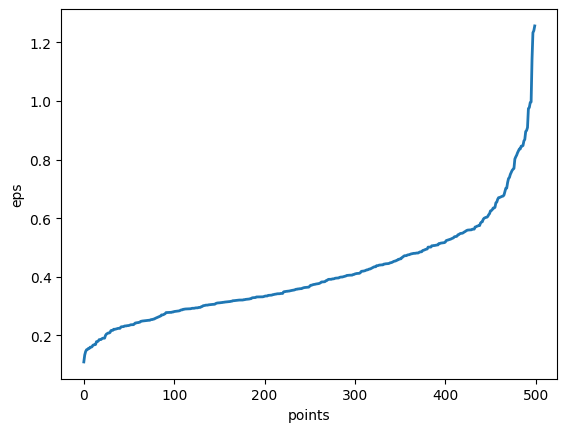

In [ ]:
# Q5a: k-distance plot (k=4), choose eps
# Graded: k_distances, eps_chosen
# YOUR CODE HERE
nbrs = NearestNeighbors(n_neighbors=4).fit(X_pca)
k_distances,ind = nbrs.kneighbors(X_pca)
k_distances = np.sort(k_distances[:,3],axis=0)
plt.plot(k_distances,linewidth=2)
plt.xlabel("points")
plt.ylabel('eps')
k_distances.shape
eps_chosen = 0.7
print("as elbow 0.7 post that is becoming kind of very gradual change ")

In [ ]:
# help(NearestNeighbors)
# NearestNeighbors(*, n_neighbors=5, radius=1.0, algorithm='auto', leaf_size=30, metric='minkowski', p=2, metric_params=None, n_jobs=None)
#  kneighbors(self, X=None, n_neighbors=None, return_distance=True)

### Q5b — Fit DBSCAN `[1 mark]`

Fit DBSCAN with `eps=eps_chosen` and `min_samples=5` on `X_pca`. Print the number of clusters found (excluding noise) and the number of noise points.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `n_clusters_db` | `int` | Number of clusters found (excluding noise) |



In [ ]:
# Q5b: Fit DBSCAN
# Graded: n_clusters_db
# YOUR CODE HERE
dbscan = DBSCAN(eps=0.7,  min_samples=5, metric='euclidean')
labels = dbscan.fit_predict(X_pca)
n_clusters_db = 484
labels

array([ 0,  0,  1,  1,  1,  1,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,
        1, -1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,
        0,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  1,
        0,  0,  0,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  1, -1,
        0,  1,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0,  0,
        0,  0,  0,  1,  0,  0,  0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,
        1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  1,  1,  0,  0,
        0,  1,  0,  1,  0,  0, -1,  0,  0,  0,  1,  0,  0,  0,  0,  0, -1,
        0,  1,  1,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,
        0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  1,  1,
        1,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  1,  0,  0,  0,  1,  1,
        0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        0,  0,  0,  1,  0

In [ ]:
# help(DBSCAN)
# DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)

### Q5c — Cluster Profiles & Comparison `[2 marks]`

Print the mean feature values per DBSCAN cluster, **excluding noise points** (label = -1). Then state one scenario where DBSCAN is preferable to K-Means and one where it is not.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `db_summary` | `DataFrame` | Mean features per DBSCAN cluster, noise excluded |



In [ ]:
# Q5c: Mean features per DBSCAN cluster (excl. noise)
# Graded: db_summary
# YOUR CODE HERE


**Q5c — When is DBSCAN better than K-Means, and when is it not? — Written answer:**

> *(Replace this text with your answer — 2–3 sentences)*


---
## Q6: Linear Regression (5 marks)


### Q6a — Baseline Model `[1 mark]`

Split the data **80/20** (`random_state=42`). Standardise the features (fit scaler on train only, transform both). Train a `LinearRegression` model on the **raw 8 features**. Print RMSE and R² on the test set.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `r2_base` | `float` | R² score on test set |



In [ ]:
# Q6a: Baseline LinearRegression on raw features
# Graded: r2_base
# (also store X_train, X_test, y_train, y_test for use in Q6b)
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X_raw,y,test_size = 0.8,random_state=42)
scaler.fit(X_train)
X_train_scaled  = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
linear_model = LinearRegression()
linear_model.fit(X_train_scaled,y_train)
y_pred =linear_model.predict(X_test)
r2_base = r2_score(y_test,y_pred)
r2_base
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

270420.07998550887


### Q6b — Pipeline Model `[2 marks]`

Build a combined feature matrix by concatenating the **PCA components** (`X_pca`) with **one-hot encoded K-Means cluster labels** (`kmeans_labels`). Train a second `LinearRegression` on this combined matrix using the same 80/20 split. Print RMSE and R².

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `rmse_pipe` | `float` | RMSE on test set |
| `r2_pipe` | `float` | R² on test set |



In [ ]:
# Q6b: LinearRegression on PCA + one-hot cluster features
# Graded: rmse_pipe, r2_pipe
# YOUR CODE HERE


### Q6c — Interpretation `[2 marks]`

Print the coefficients of both models as a table. Then explain in **3–4 sentences** why the second model performs differently from the baseline and what role the cluster labels play.


In [ ]:
# Q6c: Print coefficients of both models
# (Written explanation goes in the answer cell below)
# YOUR CODE HERE


**Q6c — Why does the pipeline model perform differently? What do cluster labels contribute? — Written answer:**

> *(Replace this text with your answer — 2–3 sentences)*
